# AI-Enabled Concrete Performance Passports for OpenBIM
## Unified, Google-Drive-backed, checkpointed training notebook

This single notebook runs the **entire** project end-to-end:

1. **Data** — download + clean the UCI concrete strength dataset (Yeh, 1998) and the public ready-mix EPD dataset (Broyles et al., 2024).
2. **Strength model** — train & compare regressors (RF / GBR / ExtraTrees / Linear, + XGBoost/LightGBM/CatBoost if available); pick the best.
3. **Explainability** — permutation / SHAP feature importance.
4. **Carbon** — ICE-factor GWP estimate + EPD-benchmarked carbon class.
5. **Passports** — generate Concrete Performance Passports (CSV + JSON + per-element JSON).
6. **OpenBIM / IDS** — IFC mapping, proposed Pset, IDS requirement matrix + conceptual IDS XML.
7. **Figures / tables / verification**.

### Two things make this notebook robust
- **Everything is saved to your Google Drive.** All data, models, figures, tables and passports are written under a project folder on Drive, so nothing is lost when the Colab runtime disconnects.
- **Checkpointing / resume.** Each phase records a checkpoint on Drive. If the runtime stops, just **re-run the notebook from the top** — completed phases are detected and skipped, and training continues where it left off.


## How resume works
- A file `_checkpoints.json` is kept in the Drive project folder.
- Before running a phase, the notebook checks (a) the checkpoint flag **and** (b) that the phase's expected output files actually exist on Drive.
- If both are satisfied the phase is **skipped**; otherwise it runs and re-records its checkpoint.
- To force a phase (or everything) to re-run, use the **reset helper** near the bottom.

> Tip: For the strength model you can enable a GPU runtime (Runtime -> Change runtime type) to speed up XGBoost, but CPU is perfectly fine — the full run takes only a few minutes.


## 1. Mount Google Drive
This is where all artefacts are persisted. Outside Colab, the notebook falls back to a local folder so it still runs.

In [1]:
import os, sys, time, json
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

DRIVE_MOUNT = "/content/drive"
if IN_COLAB:
    from google.colab import drive
    drive.mount(DRIVE_MOUNT, force_remount=False)
    DRIVE_ROOT = Path(DRIVE_MOUNT) / "MyDrive"
else:
    # Local / non-Colab fallback: persist to a folder in the home directory.
    DRIVE_ROOT = Path(os.environ.get("CPP_LOCAL_DRIVE", Path.home() / "cpp_drive"))
    DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
    print("Not running in Colab -> persisting to local folder:", DRIVE_ROOT)

assert DRIVE_ROOT.exists(), f"Drive root not found: {DRIVE_ROOT}"
print("Drive root:", DRIVE_ROOT)

Mounted at /content/drive
Drive root: /content/drive/MyDrive


## 2. Settings, clone the code, install dependencies
- `PROJECT_NAME` is the folder created on your Drive that holds **all** outputs.
- The repository **code** is cloned to fast local storage each session (cheap, re-clonable); the **data/models/outputs** live on Drive (expensive, persistent).

In [2]:
# ---- Settings you may edit -------------------------------------------------
PROJECT_NAME = "ConcretePerformancePassport"   # Drive folder for all artefacts
REPO_URL     = "https://github.com/sayyedalimrj/Paper.git"
REPO_BRANCH  = "main"
N_PASSPORTS  = 30          # number of demonstration passports to generate
USE_SHAP     = False       # True = SHAP explanations (slower); False = permutation importance
FORCE_OFFLINE = False      # True = never hit the network (uses cached data only)
# ---------------------------------------------------------------------------

# Persistent project root on Drive: all data/ and outputs/ go here.
PROJECT_ROOT = DRIVE_ROOT / PROJECT_NAME
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
print("Persistent project root (Drive):", PROJECT_ROOT)

# Local clone location for the source code.
if IN_COLAB:
    CODE_DIR = Path("/content/Paper")
else:
    # If we are already inside the repo, use it; else clone next to cwd.
    here = Path.cwd()
    CODE_DIR = here if (here / "src" / "config.py").exists() else here / "Paper"

if not (CODE_DIR / "src" / "config.py").exists():
    print("Cloning repository ->", CODE_DIR)
    import subprocess
    subprocess.run(["git", "clone", "--depth", "1", "--branch", REPO_BRANCH, REPO_URL, str(CODE_DIR)], check=True)
else:
    print("Source code already present ->", CODE_DIR)

# Make the `src` package importable.
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

# Install dependencies (quiet). Most are pre-installed in Colab.
req = CODE_DIR / "requirements.txt"
if req.exists():
    print("Installing dependencies from", req, "...")
    os.system(f"pip install -q -r '{req}' 2>/dev/null")
else:
    os.system("pip install -q numpy pandas scipy scikit-learn xgboost joblib matplotlib requests openpyxl xlrd lxml jinja2 tabulate pyyaml 2>/dev/null")
print("Dependencies ready.")

Persistent project root (Drive): /content/drive/MyDrive/ConcretePerformancePassport
Cloning repository -> /content/Paper
Installing dependencies from /content/Paper/requirements.txt ...
Dependencies ready.


## 3. Point the project at Drive and import the modules
`CPP_PROJECT_ROOT` is read by `src/config.py` **at import time**, so it must be set *before* importing. This redirects every `data/` and `outputs/` path onto your Drive folder.

In [3]:
# Redirect ALL data/outputs onto Drive BEFORE importing config.
os.environ["CPP_PROJECT_ROOT"] = str(PROJECT_ROOT)
if FORCE_OFFLINE:
    os.environ["USE_CACHED_ONLY"] = "1"

from src import (config, utils, data_download, data_cleaning,
                 train_strength_model, explainability, train_carbon_model,
                 generate_passports, ifc_mapping, pipeline)

config.ensure_dirs()
utils.set_seed()

print("config.PROJECT_ROOT :", config.PROJECT_ROOT)
print("data ->", config.DATA_DIR)
print("outputs ->", config.OUTPUTS_DIR)
assert str(config.PROJECT_ROOT) == str(PROJECT_ROOT), "Project root not redirected to Drive!"
print("\nAll artefacts will be saved on Drive at:", PROJECT_ROOT)

[2026-06-13 12:26:52,983] INFO cpp: Random seed set to 42
INFO:cpp:Random seed set to 42


config.PROJECT_ROOT : /content/drive/MyDrive/ConcretePerformancePassport
data -> /content/drive/MyDrive/ConcretePerformancePassport/data
outputs -> /content/drive/MyDrive/ConcretePerformancePassport/outputs

All artefacts will be saved on Drive at: /content/drive/MyDrive/ConcretePerformancePassport


## 4. Checkpoint manager (enables resume)
`run_phase(name, fn, outputs=[...])` runs a phase only if it has not already completed **and** produced its outputs. Results are cached in-memory per session too.

In [4]:
CKPT_PATH = PROJECT_ROOT / "_checkpoints.json"

class Checkpoints:
    def __init__(self, path):
        self.path = Path(path)
        self.state = {}
        if self.path.exists():
            try:
                self.state = json.loads(self.path.read_text())
            except Exception:
                self.state = {}
        self._cache = {}

    def _save(self):
        self.path.write_text(json.dumps(self.state, indent=2, default=str))

    def is_done(self, name, outputs):
        if not self.state.get(name, {}).get("done"):
            return False
        # Verify the recorded output files still exist on Drive.
        for o in outputs or []:
            if not Path(o).exists():
                return False
        return True

    def run_phase(self, name, fn, outputs=None, force=False):
        outputs = [str(o) for o in (outputs or [])]
        if not force and self.is_done(name, outputs):
            print(f"[SKIP] '{name}' already complete (checkpoint + outputs present).")
            return self._cache.get(name)
        print(f"[RUN ] '{name}' ...")
        t0 = time.time()
        result = fn()
        dt = time.time() - t0
        missing = [o for o in outputs if not Path(o).exists()]
        if missing:
            raise RuntimeError(f"Phase '{name}' finished but expected outputs are missing: {missing}")
        self.state[name] = {"done": True, "seconds": round(dt, 2),
                            "finished_utc": utils.utc_timestamp(), "outputs": outputs}
        self._save()
        self._cache[name] = result
        print(f"[DONE] '{name}' in {dt:.1f}s  ({len(outputs)} output(s) verified)")
        return result

    def reset(self, name=None):
        if name is None:
            self.state = {}
            print("Reset ALL checkpoints (outputs on Drive are kept; re-running will overwrite them).")
        else:
            self.state.pop(name, None)
            print(f"Reset checkpoint: {name}")
        self._save()

    def status(self):
        import pandas as pd
        if not self.state:
            print("No checkpoints recorded yet.")
            return
        rows = [{"phase": k, "done": v.get("done"), "seconds": v.get("seconds"),
                 "finished_utc": v.get("finished_utc")} for k, v in self.state.items()]
        return pd.DataFrame(rows)

ckpt = Checkpoints(CKPT_PATH)
print("Checkpoint file:", CKPT_PATH)
display(ckpt.status())

Checkpoint file: /content/drive/MyDrive/ConcretePerformancePassport/_checkpoints.json
No checkpoints recorded yet.


None

## 5. (Optional) Source availability check
A quick reachability probe of the public sources. Safe to skip if offline.

In [6]:
if not FORCE_OFFLINE:
    import requests
    SOURCES = {
        "UCI .xls": "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls",
        "Mendeley EPD API": "https://data.mendeley.com/public-files/datasets/r4jgxk2mhn/files/23973d63-2b93-45cb-8f1d-2b013e905b20/file_downloaded",
    }
    for name, url in SOURCES.items():
        try:
            r = requests.head(url, timeout=20, allow_redirects=True)
            print(f"  {name}: reachable (HTTP {r.status_code})")
        except Exception as e:
            print(f"  {name}: not reachable now ({type(e).__name__}) — fallbacks will be used.")
else:
    print("FORCE_OFFLINE=True -> skipping network checks; cached data will be used.")

  UCI .xls: reachable (HTTP 200)
  Mendeley EPD API: reachable (HTTP 403)


## 6. Phase 1 — Data: download + clean
Downloads the UCI strength dataset (with OpenML fallback) and writes the cleaned, feature-engineered CSV.

In [7]:
import pandas as pd

def _phase_data():
    data_download.download_concrete_strength()
    clean_path = data_cleaning.clean()
    df = pd.read_csv(clean_path)
    ds = pipeline.dataset_summary(df)
    return {"clean_path": str(clean_path), "summary": ds, "n_rows": len(df)}

data_res = ckpt.run_phase(
    "data",
    _phase_data,
    outputs=[config.PROCESSED_DIR / "concrete_strength_clean.csv",
             config.TABLES_DIR / "dataset_summary.csv"],
)

# Always (re)load the cleaned frame for later cells, even on skip.
clean_csv = config.PROCESSED_DIR / "concrete_strength_clean.csv"
df_clean = pd.read_csv(clean_csv)
print("Cleaned dataset:", df_clean.shape)
display(df_clean.head())
display(pd.read_csv(config.TABLES_DIR / "dataset_summary.csv"))

[2026-06-13 12:28:24,618] INFO data_download: Downloading https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls
INFO:data_download:Downloading https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls


[RUN ] 'data' ...


[2026-06-13 12:28:25,650] INFO data_download: Saved -> /content/drive/MyDrive/ConcretePerformancePassport/data/raw/Concrete_Data.xls (124928 bytes)
INFO:data_download:Saved -> /content/drive/MyDrive/ConcretePerformancePassport/data/raw/Concrete_Data.xls (124928 bytes)
[2026-06-13 12:28:25,786] INFO data_download: Wrote normalised raw CSV -> /content/drive/MyDrive/ConcretePerformancePassport/data/raw/concrete_strength_raw.csv (shape=(1030, 9))
INFO:data_download:Wrote normalised raw CSV -> /content/drive/MyDrive/ConcretePerformancePassport/data/raw/concrete_strength_raw.csv (shape=(1030, 9))
[2026-06-13 12:28:25,796] INFO cpp: Saved JSON -> /content/drive/MyDrive/ConcretePerformancePassport/data/raw/provenance.json
INFO:cpp:Saved JSON -> /content/drive/MyDrive/ConcretePerformancePassport/data/raw/provenance.json
[2026-06-13 12:28:25,813] INFO data_cleaning: Validation flagged 0 potentially anomalous rows.
INFO:data_cleaning:Validation flagged 0 potentially anomalous rows.
[2026-06-13 12

[DONE] 'data' in 1.3s  (2 output(s) verified)
Cleaned dataset: (1030, 13)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,total_binder,water_cement_ratio,water_binder_ratio,scm_fraction
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111,540.0,0.3000,0.3000,0.0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366,540.0,0.3000,0.3000,0.0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535,475.0,0.6857,0.4800,0.3
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780,475.0,0.6857,0.4800,0.3
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075,331.0,0.9668,0.5801,0.4


,variable,n_non_null,mean,std,min,25%,50%,75%,max
0,cement,1030,281.17,104.51,102.00,192.38,272.90,350.00,540.00
1,blast_furnace_slag,1030,73.90,86.28,0.00,0.00,22.00,142.95,359.40
2,fly_ash,1030,54.19,64.00,0.00,0.00,0.00,118.27,200.10
3,water,1030,181.57,21.36,121.75,164.90,185.00,192.00,247.00
4,superplasticizer,1030,6.20,5.97,0.00,0.00,6.35,10.16,32.20
5,coarse_aggregate,1030,972.92,77.75,801.00,932.00,968.00,1029.40,1145.00
6,fine_aggregate,1030,773.58,80.18,594.00,730.95,779.51,824.00,992.60
7,age,1030,45.66,63.17,1.00,7.00,28.00,56.00,365.00
8,compressive_strength,1030,35.82,16.71,2.33,23.71,34.44,46.14,82.60
9,total_binder,1030,409.25,92.78,200.00,336.38,391.35,483.70,640.00


## 7. Phase 2 — Train the compressive-strength model
Trains and compares all available regressors, evaluates on a hold-out split + 5-fold CV, and persists the **best** model (with an uncertainty model + residual std) to Drive.

In [8]:
def _phase_strength():
    res = train_strength_model.train(clean_csv)
    pipeline.model_performance_summary(res["metrics"], res["best_name"])
    return {"best_name": res["best_name"], "features": res["features"]}

strength_res = ckpt.run_phase(
    "strength_model",
    _phase_strength,
    outputs=[config.MODELS_DIR / "best_strength_model.pkl",
             config.TABLES_DIR / "strength_model_metrics.csv",
             config.FIGURES_DIR / "strength_model_comparison.png"],
)

metrics = pd.read_csv(config.TABLES_DIR / "strength_model_metrics.csv")
print("Model comparison (sorted by hold-out R2):")
display(metrics)
import joblib
_art = joblib.load(config.MODELS_DIR / "best_strength_model.pkl")
print("Best model:", _art["model_name"], "| trained:", _art["trained_utc"])

[2026-06-13 12:28:36,158] INFO cpp: Random seed set to 42
INFO:cpp:Random seed set to 42
[2026-06-13 12:28:36,170] INFO train_strength_model: Training on 1030 rows, 8 features.
INFO:train_strength_model:Training on 1030 rows, 8 features.


[RUN ] 'strength_model' ...


[2026-06-13 12:28:41,168] INFO train_strength_model: CatBoost not available (ModuleNotFoundError) — skipping.
INFO:train_strength_model:CatBoost not available (ModuleNotFoundError) — skipping.
[2026-06-13 12:28:43,624] INFO train_strength_model: LinearRegression R2=0.628 RMSE=9.80 MAE=7.75 CV_R2=0.601
INFO:train_strength_model:LinearRegression R2=0.628 RMSE=9.80 MAE=7.75 CV_R2=0.601
[2026-06-13 12:28:49,411] INFO train_strength_model: RandomForest     R2=0.881 RMSE=5.54 MAE=3.78 CV_R2=0.907
INFO:train_strength_model:RandomForest     R2=0.881 RMSE=5.54 MAE=3.78 CV_R2=0.907
[2026-06-13 12:28:50,941] INFO train_strength_model: GradientBoosting R2=0.881 RMSE=5.54 MAE=4.10 CV_R2=0.902
INFO:train_strength_model:GradientBoosting R2=0.881 RMSE=5.54 MAE=4.10 CV_R2=0.902
[2026-06-13 12:28:54,170] INFO train_strength_model: ExtraTrees       R2=0.890 RMSE=5.32 MAE=3.41 CV_R2=0.917
INFO:train_strength_model:ExtraTrees       R2=0.890 RMSE=5.32 MAE=3.41 CV_R2=0.917
[2026-06-13 12:28:56,041] INFO trai

[DONE] 'strength_model' in 33.3s  (3 output(s) verified)
Model comparison (sorted by hold-out R2):


,model,r2,rmse,mae,mape,cv_r2_mean,cv_r2_std
0,LightGBM,0.923927,4.427485,2.906317,9.371240,0.931156,0.008814
1,XGBoost,0.923314,4.445273,3.137416,10.145021,0.933615,0.006272
2,ExtraTrees,0.890042,5.322985,3.411450,10.598766,0.917074,0.014595
3,GradientBoosting,0.880798,5.542216,4.100611,13.071047,0.901976,0.014251
4,RandomForest,0.880710,5.544250,3.783016,12.392296,0.906690,0.015800
5,LinearRegression,0.627542,9.796708,7.745393,29.276299,0.600636,0.047811


Best model: LightGBM | trained: 2026-06-13T12:29:08Z


## 8. Phase 3 — Explainability
Feature importance for the best model (permutation by default; set `USE_SHAP=True` in settings for SHAP).

In [9]:
def _phase_explain():
    art = joblib.load(config.MODELS_DIR / "best_strength_model.pkl")
    X = df_clean[art["features"]].astype(float)
    y = df_clean[config.STRENGTH_TARGET].astype(float)
    imp, method = explainability.explain(art["model"], X, art["features"], y, use_shap=USE_SHAP)
    return {"method": method}

explain_res = ckpt.run_phase(
    "explainability",
    _phase_explain,
    outputs=[config.TABLES_DIR / "strength_feature_importance_values.csv",
             config.FIGURES_DIR / "strength_explainability.png"],
)
display(pd.read_csv(config.TABLES_DIR / "strength_feature_importance_values.csv"))

[2026-06-13 12:29:20,186] INFO explainability: use_shap=False -> using permutation/impurity importance.
INFO:explainability:use_shap=False -> using permutation/impurity importance.


[RUN ] 'explainability' ...


[2026-06-13 12:29:21,711] INFO explainability: Permutation importance succeeded.
INFO:explainability:Permutation importance succeeded.
[2026-06-13 12:29:21,864] INFO explainability: Explainability method used: Permutation importance
INFO:explainability:Explainability method used: Permutation importance


[DONE] 'explainability' in 1.8s  (2 output(s) verified)


,feature,importance,method
0,age,0.860100,Permutation importance
1,cement,0.487644,Permutation importance
2,water,0.202233,Permutation importance
3,blast_furnace_slag,0.185096,Permutation importance
4,superplasticizer,0.086831,Permutation importance
5,fine_aggregate,0.046453,Permutation importance
6,coarse_aggregate,0.026738,Permutation importance
7,fly_ash,0.003219,Permutation importance


## 9. Phase 4 — Carbon: EPD benchmark + ICE estimate
Downloads the compiled EPD dataset (~80 MB; cached to Drive so it only downloads once), builds per-strength-class GWP benchmarks, and writes ICE per-constituent factors.

In [10]:
def _phase_carbon():
    r = train_carbon_model.run()
    return {"source_note": r["source_note"]}

carbon_res = ckpt.run_phase(
    "carbon",
    _phase_carbon,
    outputs=[config.EXTERNAL_DIR / "ice_carbon_factors.csv",
             config.TABLES_DIR / "carbon_benchmark_summary.csv",
             config.FIGURES_DIR / "carbon_distribution.png"],
)
print("EPD source:", (carbon_res or {}).get("source_note", "(skipped — already done)"))
display(pd.read_csv(config.TABLES_DIR / "carbon_benchmark_summary.csv"))

[2026-06-13 12:29:25,113] INFO cpp: Random seed set to 42
INFO:cpp:Random seed set to 42
[2026-06-13 12:29:25,135] INFO train_carbon_model: Wrote ICE factors -> /content/drive/MyDrive/ConcretePerformancePassport/data/external/ice_carbon_factors.csv
INFO:train_carbon_model:Wrote ICE factors -> /content/drive/MyDrive/ConcretePerformancePassport/data/external/ice_carbon_factors.csv
[2026-06-13 12:29:25,176] WARNING train_carbon_model: EPD download failed (Expecting value: line 1 column 1 (char 0)) -> synthetic fallback.
[2026-06-13 12:29:25,186] INFO train_carbon_model: EPD usable rows: 2000 (SYNTHETIC fallback (download unavailable))
INFO:train_carbon_model:EPD usable rows: 2000 (SYNTHETIC fallback (download unavailable))
[2026-06-13 12:29:25,211] INFO train_carbon_model: Saved carbon benchmark summary -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/carbon_benchmark_summary.csv
INFO:train_carbon_model:Saved carbon benchmark summary -> /content/drive/MyDrive/ConcreteP

[RUN ] 'carbon' ...


[2026-06-13 12:29:25,701] INFO train_carbon_model: Saved figure -> outputs/figures/carbon_distribution.png
INFO:train_carbon_model:Saved figure -> outputs/figures/carbon_distribution.png
[2026-06-13 12:29:26,932] INFO train_carbon_model: Saved GWP model metrics (R2=0.512) -> outputs/tables/carbon_model_metrics.csv
INFO:train_carbon_model:Saved GWP model metrics (R2=0.512) -> outputs/tables/carbon_model_metrics.csv


[DONE] 'carbon' in 1.8s  (3 output(s) verified)
EPD source: SYNTHETIC fallback (download unavailable)


,strength_class_psi,n,mean,median,q1,q3,min,max
0,<3000,429,228.9,231.6,196.3,262.0,120.0,361.8
1,3000-3999,487,279.1,279.2,246.6,310.6,132.6,432.2
2,4000-4999,572,323.0,321.5,291.8,352.4,195.4,452.0
3,5000-5999,326,366.2,370.0,333.6,397.2,222.9,494.3
4,6000-7999,180,417.6,419.7,385.4,454.5,289.6,530.0
5,8000+,6,499.5,504.7,485.2,539.6,408.3,549.2


## 10. Phase 5 — Generate Concrete Performance Passports
Combines mix/test data, ML prediction + approximate prediction interval + risk class, ICE/EPD carbon class, a rule-based QA/QC decision, and an evidence/provenance layer. Writes a CSV, a combined JSON (with JSON Schema), and one JSON per element.

In [11]:
def _phase_passports():
    out = generate_passports.generate(n=N_PASSPORTS)
    return {"csv": str(out["csv"]), "n": out["n"]}

pp_res = ckpt.run_phase(
    "passports",
    _phase_passports,
    outputs=[config.TABLES_DIR / "concrete_performance_passports.csv",
             config.TABLES_DIR / "concrete_performance_passports.json",
             config.FIGURES_DIR / "risk_class_distribution.png"],
)
passports = pd.read_csv(config.TABLES_DIR / "concrete_performance_passports.csv")
print("Passports:", passports.shape, "| per-element JSON files:",
      len(list(config.PASSPORTS_DIR.glob("*.json"))))
display(passports[["element_id","element_type","required_strength_mpa","predicted_strength_mpa",
                   "risk_class","qa_qc_decision","carbon_class","evidence_level"]].head(12))

[2026-06-13 12:29:30,834] INFO cpp: Random seed set to 42
INFO:cpp:Random seed set to 42
[2026-06-13 12:29:31,001] WARNING train_carbon_model: EPD download failed (Expecting value: line 1 column 1 (char 0)) -> synthetic fallback.
[2026-06-13 12:29:31,012] INFO train_carbon_model: EPD usable rows: 2000 (SYNTHETIC fallback (download unavailable))
INFO:train_carbon_model:EPD usable rows: 2000 (SYNTHETIC fallback (download unavailable))


[RUN ] 'passports' ...


[2026-06-13 12:29:31,040] INFO train_carbon_model: Saved carbon benchmark summary -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/carbon_benchmark_summary.csv
INFO:train_carbon_model:Saved carbon benchmark summary -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/carbon_benchmark_summary.csv
[2026-06-13 12:29:31,247] INFO cpp: Saved JSON -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/passports/EL-BEA-001.json
INFO:cpp:Saved JSON -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/passports/EL-BEA-001.json
[2026-06-13 12:29:31,260] INFO cpp: Saved JSON -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/passports/EL-COL-002.json
INFO:cpp:Saved JSON -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/passports/EL-COL-002.json
[2026-06-13 12:29:31,272] INFO cpp: Saved JSON -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/passports/EL-SLA-003.json
INFO:cpp:Saved JSON -> /content/drive/MyDrive/

[DONE] 'passports' in 1.1s  (3 output(s) verified)
Passports: (31, 43) | per-element JSON files: 30


,element_id,element_type,required_strength_mpa,predicted_strength_mpa,risk_class,qa_qc_decision,carbon_class,evidence_level
0,EL-BEA-001,beam,32.0,51.52,Low,Accept,Low,C
1,EL-COL-002,column,40.0,42.22,High,Retest,Low,C
2,EL-SLA-003,slab,30.0,76.78,Low,Accept,High,C
3,EL-WAL-004,wall,30.0,33.55,Low,Accept,Typical,C
4,EL-FOO-005,footing,25.0,10.68,High,Retest,Low,C
5,EL-PIL-006,pile,35.0,44.32,Low,Accept,Low,C
6,EL-BRI-007,bridge_deck,35.0,23.99,High,Retest,Low,C
7,EL-PIE-008,pier,40.0,48.87,Medium,Accept,Low,C
8,EL-BEA-009,beam,32.0,35.43,Medium,Accept,Low,C
9,EL-COL-010,column,40.0,46.12,Medium,Accept,Low,C


## 11. Phase 6 — OpenBIM / IDS mapping
Passport-field to IFC mapping, the proposed `Pset_ConcretePerformancePassport`, an IDS requirement matrix, and a conceptual IDS XML. `ifcopenshell` is optional (graceful fallback).

In [12]:
def _phase_openbim():
    r = ifc_mapping.build_mapping()
    return {"ifc_note": r["ifc_note"]}

bim_res = ckpt.run_phase(
    "openbim",
    _phase_openbim,
    outputs=[config.TABLES_DIR / "openbim_mapping.csv",
             config.TABLES_DIR / "ids_requirement_matrix.csv",
             config.TABLES_DIR / "Pset_ConcretePerformancePassport.csv",
             config.CHAPTER_DIR / "concrete_performance_passport.ids.xml"],
)
print("IFC note:", (bim_res or {}).get("ifc_note", "(skipped — already done)"))
display(pd.read_csv(config.TABLES_DIR / "ids_requirement_matrix.csv").head(13))

[2026-06-13 12:29:38,957] INFO ifc_mapping: Saved OpenBIM mapping -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/openbim_mapping.csv
INFO:ifc_mapping:Saved OpenBIM mapping -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/openbim_mapping.csv
[2026-06-13 12:29:38,967] INFO ifc_mapping: Saved proposed Pset -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/Pset_ConcretePerformancePassport.csv
INFO:ifc_mapping:Saved proposed Pset -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/Pset_ConcretePerformancePassport.csv
[2026-06-13 12:29:38,976] INFO ifc_mapping: Saved IDS requirement matrix -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/ids_requirement_matrix.csv
INFO:ifc_mapping:Saved IDS requirement matrix -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/ids_requirement_matrix.csv
[2026-06-13 12:29:38,985] INFO ifc_mapping: Saved conceptual IDS XML -> /content/drive/MyDriv

[RUN ] 'openbim' ...
[DONE] 'openbim' in 0.0s  (4 output(s) verified)
IFC note: ifcopenshell not available (ModuleNotFoundError); skipping IFC extraction demo. Conceptual mapping + IDS artefacts were produced instead (no blocking).


,requirement_id,requirement_name,target_object_or_material,required_property,expected_type_or_value,importance,rationale,related_passport_field
0,IDS-CPP-01,Concrete material assigned,IfcBeam/IfcColumn/IfcSlab/IfcWall/IfcFooting/I...,IfcMaterial.Name,"non-empty string (concrete class, e.g. C30/37)",required,Every concrete element must declare its materi...,material_class
1,IDS-CPP-02,Specified compressive strength present,concrete IfcElement,Pset_MaterialConcrete.CompressiveStrength,>0 Pa,required,Required strength must be available to evaluat...,required_strength_mpa
2,IDS-CPP-03,Mix constituents declared,IfcMaterialConstituentSet,"IfcMaterialConstituent (Cement, Water, SCM, Ag...",constituents present,optional,Supports sustainability + traceability,cement|water|scm|aggregate
3,IDS-CPP-04,Predicted strength present,concrete IfcElement,Pset_ConcretePerformancePassport.PredictedComp...,>0 Pa,required,Core ML output of the passport,predicted_strength_mpa
4,IDS-CPP-05,Risk class declared,concrete IfcElement,Pset_ConcretePerformancePassport.RiskClass,"enum {Low,Medium,High}",required,Drives prioritisation/decision,risk_class
5,IDS-CPP-06,QA/QC decision declared,concrete IfcElement,Pset_ConcretePerformancePassport.QADecision,"enum {Accept,Review,Hold/Retest,Missing/Insuff...",required,The actionable QA outcome,qa_decision
6,IDS-CPP-07,Prediction uncertainty present,concrete IfcElement,Pset_ConcretePerformancePassport.PredictionUnc...,>=0 Pa,optional,Quantifies confidence,prediction_uncertainty_mpa
7,IDS-CPP-08,Carbon class declared,concrete IfcElement,Pset_ConcretePerformancePassport.CarbonClass,"enum {Low,Typical,High}",optional,Sustainability decision support,carbon_class
8,IDS-CPP-09,Embodied carbon value present,concrete IfcElement,Pset_ConcretePerformancePassport.GWP_A1A3,>0 kgCO2e/m3,optional,Enables benchmarking,gwp_estimate_kgco2e_per_m3
9,IDS-CPP-10,Model reference present,concrete IfcElement,Pset_ConcretePerformancePassport.ModelReference,non-empty string,optional,Traceability/auditability of the prediction,model_name


## 12. Phase 7 — Framework diagram + limitations table

In [13]:
def _phase_figures():
    pipeline.framework_diagram()
    pipeline.limitations_table()
    return {}

fig_res = ckpt.run_phase(
    "figures_tables",
    _phase_figures,
    outputs=[config.FIGURES_DIR / "framework_diagram.png",
             config.TABLES_DIR / "limitations_and_future_work.csv"],
)
display(pd.read_csv(config.TABLES_DIR / "limitations_and_future_work.csv"))

[RUN ] 'figures_tables' ...


[2026-06-13 12:29:44,320] INFO pipeline: Saved framework diagram -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/figures/framework_diagram.png
INFO:pipeline:Saved framework diagram -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/figures/framework_diagram.png
[2026-06-13 12:29:44,334] INFO pipeline: Saved limitations/future-work -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/limitations_and_future_work.csv
INFO:pipeline:Saved limitations/future-work -> /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/limitations_and_future_work.csv


[DONE] 'figures_tables' in 0.3s  (2 output(s) verified)


,limitation,description,future_work
0,Strength dataset scope,UCI dataset uses 8 mix-design inputs only (no ...,Incorporate richer mix/curing/chemistry datase...
1,Durability not modelled,"No clean, complete public durability dataset; ...","Integrate a vetted durability dataset (e.g., c..."
2,Carbon estimate,ICE per-constituent factors are generic cradle...,Use product/region-specific verified EPDs; exp...
3,BIM context illustrative,Element IDs/types/required strengths/volumes a...,Apply to a real IFC project model with project...
4,IFC/IDS specification-level,Custom Pset + IDS are conceptual; not certifie...,"Author full IFC, validate IDS in BIMcollab/Ifc..."
5,Prediction uncertainty,Uncertainty via ensemble spread/residual std; ...,Adopt conformal prediction or quantile models ...
6,No causal claims,"Feature importance/SHAP are associational, not...",Combine with mechanistic/physics-informed models.


## 13. Verify all artefacts & preview figures
Confirms every expected file exists on Drive and renders the key figures inline.

=== Artefact verification (on Drive) ===
  [OK] Cleaned data         /content/drive/MyDrive/ConcretePerformancePassport/data/processed/concrete_strength_clean.csv  (83,882 bytes)
  [OK] Best model           /content/drive/MyDrive/ConcretePerformancePassport/outputs/models/best_strength_model.pkl  (16,032,472 bytes)
  [OK] Strength metrics     /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/strength_model_metrics.csv  (795 bytes)
  [OK] Feature importance   /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/strength_feature_importance_values.csv  (465 bytes)
  [OK] Carbon benchmark     /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/carbon_benchmark_summary.csv  (337 bytes)
  [OK] ICE factors          /content/drive/MyDrive/ConcretePerformancePassport/data/external/ice_carbon_factors.csv  (954 bytes)
  [OK] Passports CSV        /content/drive/MyDrive/ConcretePerformancePassport/outputs/tables/concrete_performance_passports.csv  (46,134 

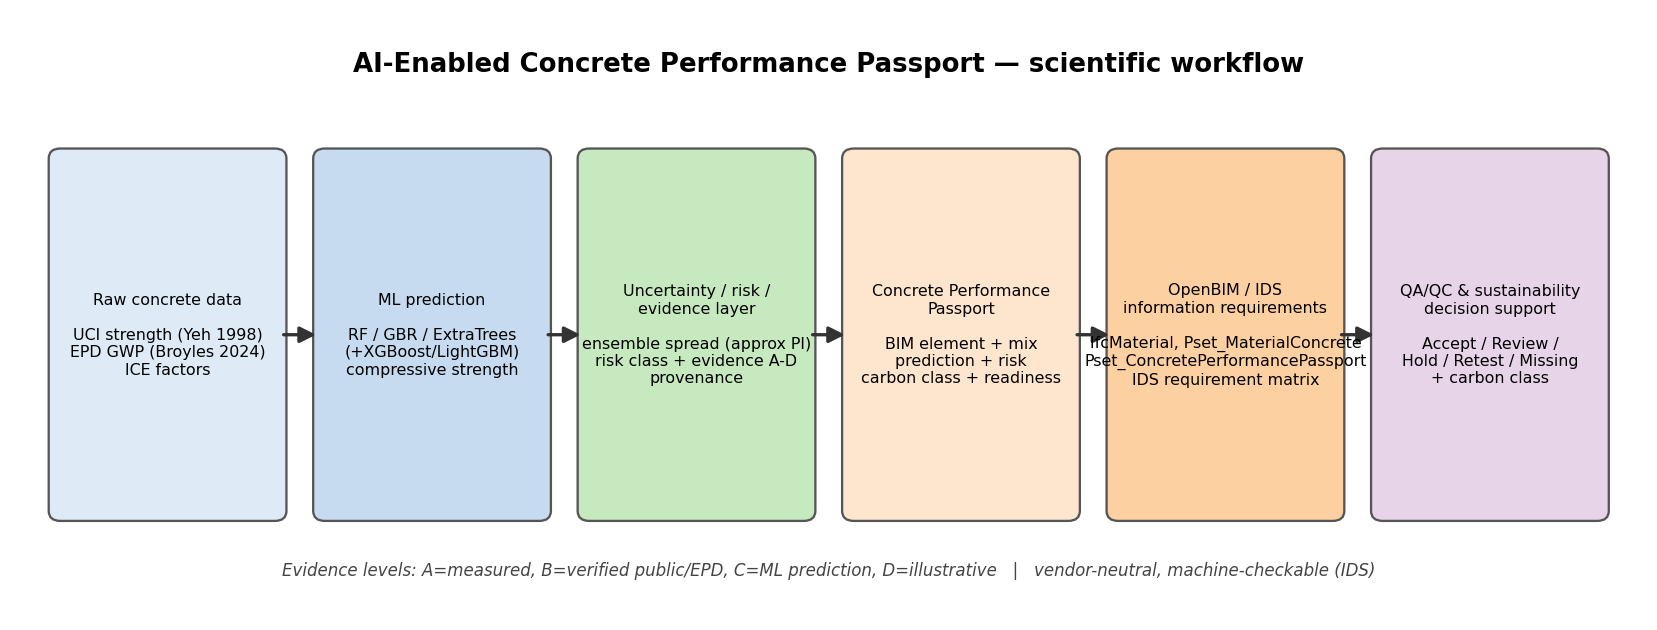

strength_model_comparison.png


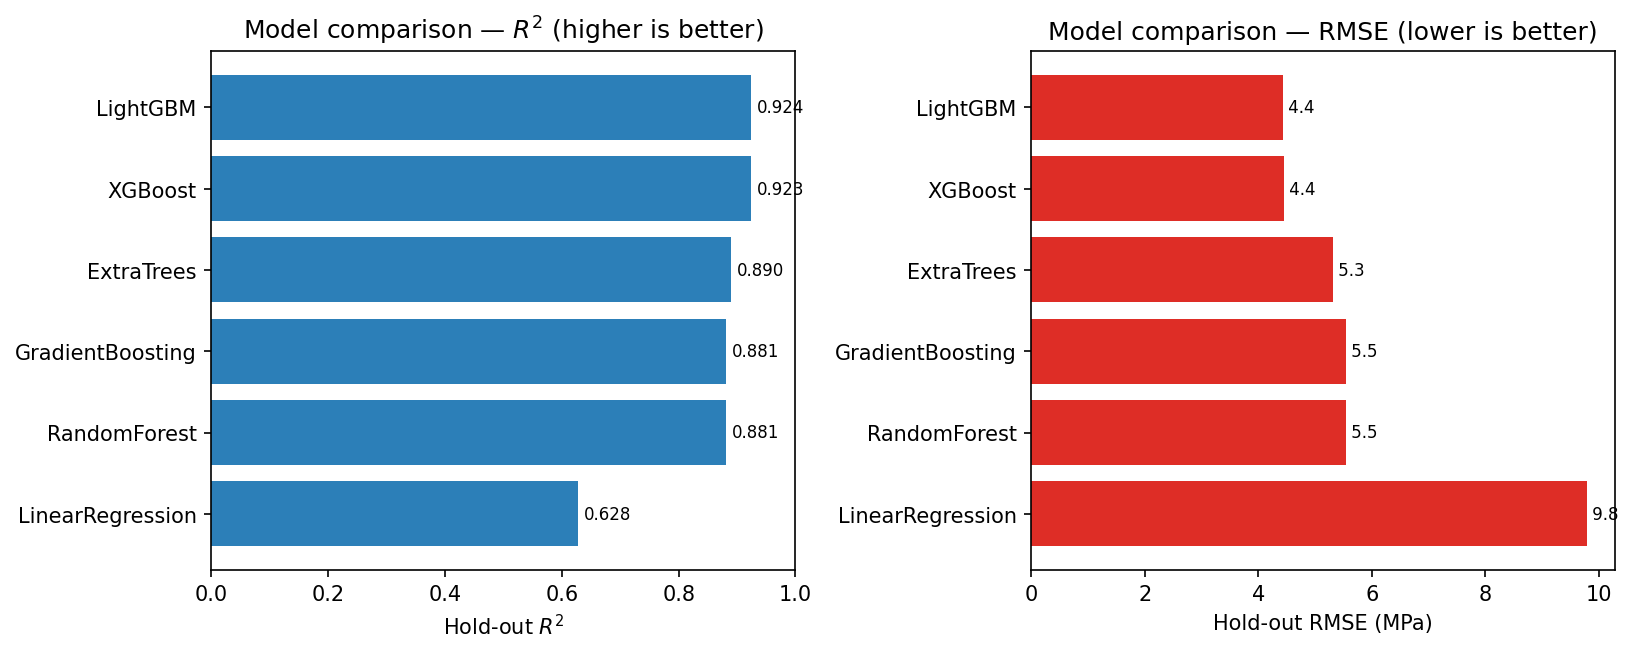

strength_feature_importance.png


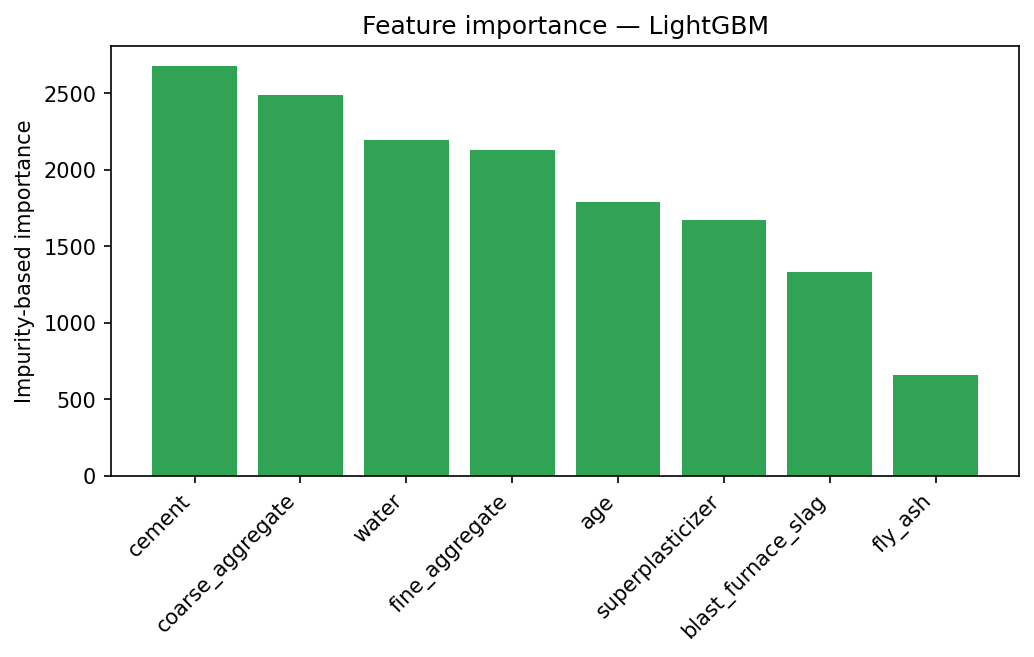

strength_explainability.png


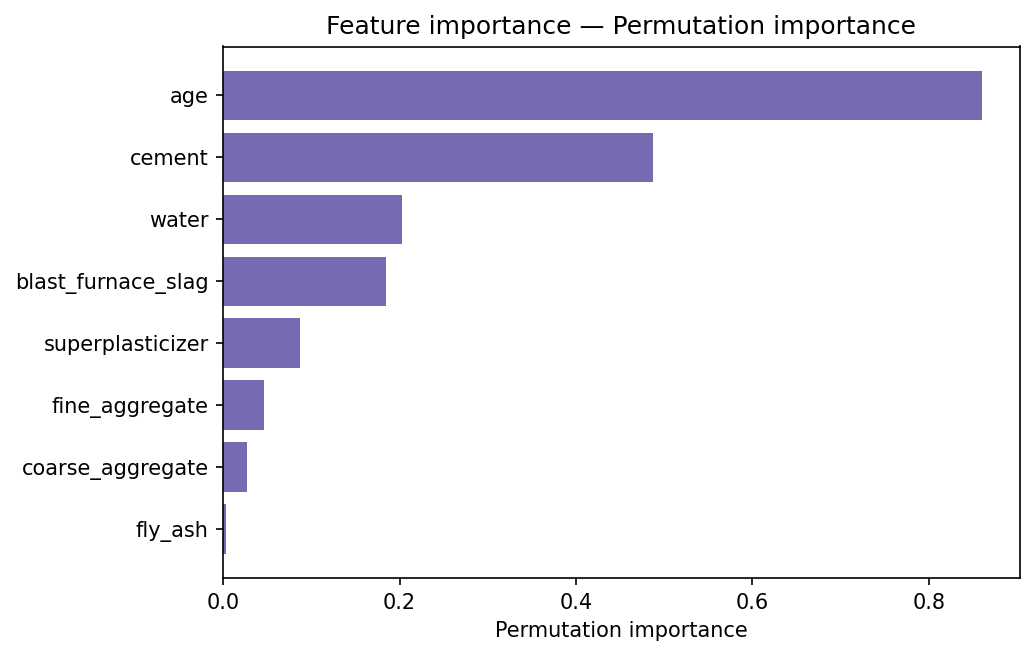

carbon_distribution.png


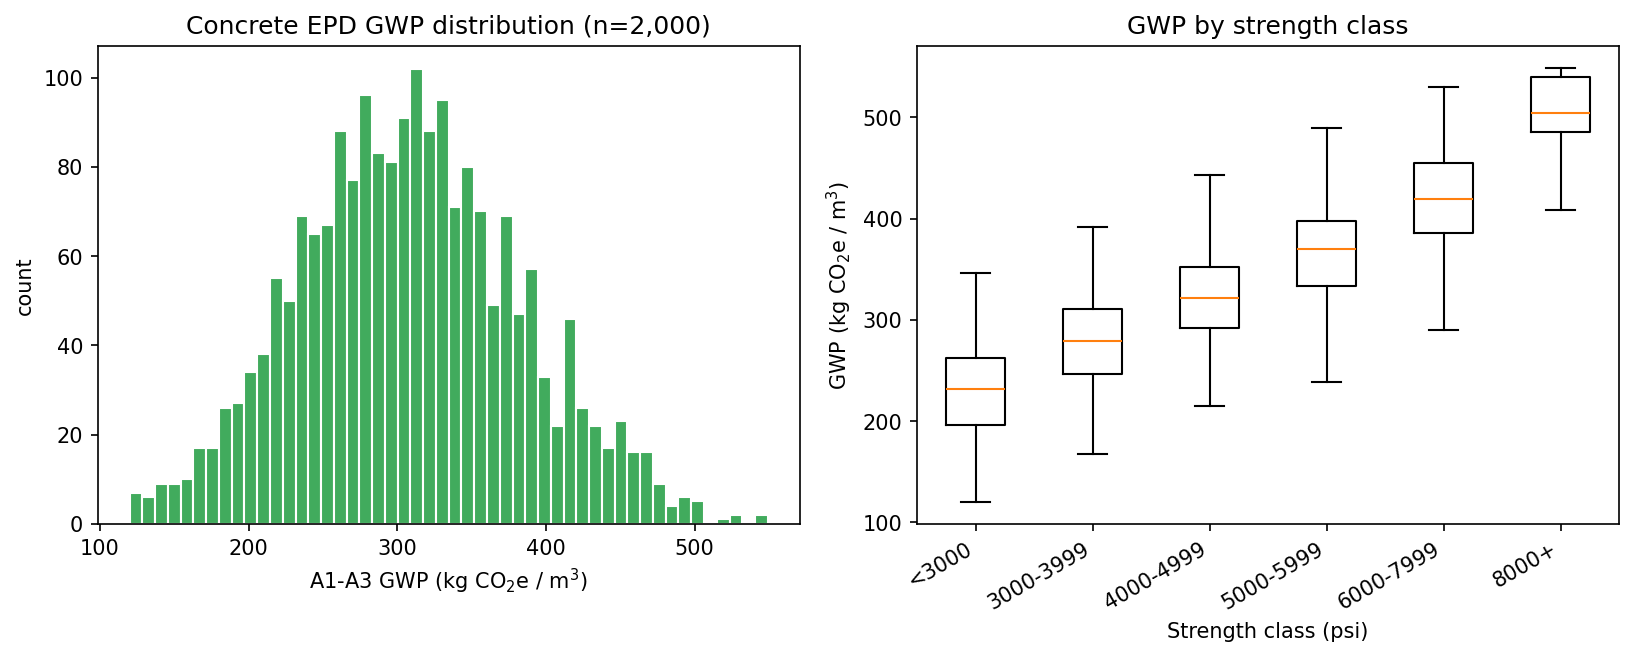

risk_class_distribution.png


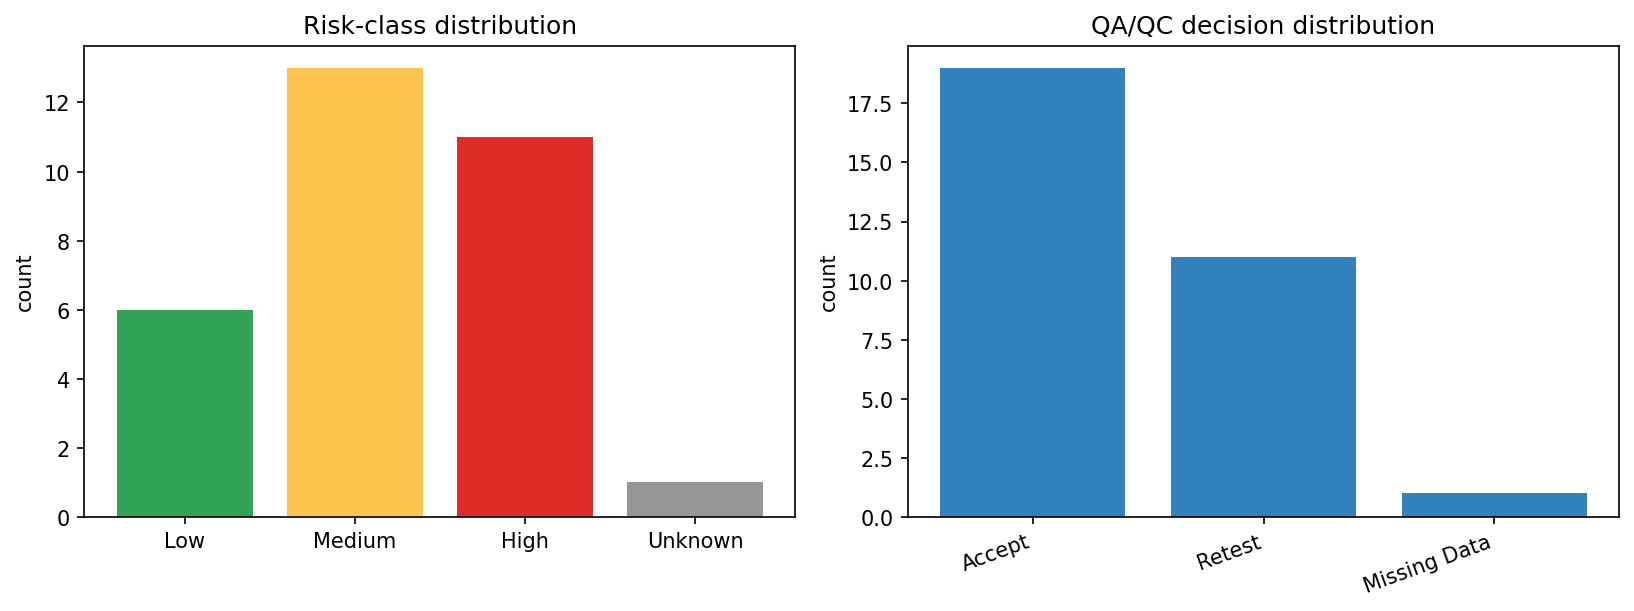

In [14]:
from IPython.display import Image, display as idisplay

EXPECTED = {
    "Cleaned data": config.PROCESSED_DIR / "concrete_strength_clean.csv",
    "Best model": config.MODELS_DIR / "best_strength_model.pkl",
    "Strength metrics": config.TABLES_DIR / "strength_model_metrics.csv",
    "Feature importance": config.TABLES_DIR / "strength_feature_importance_values.csv",
    "Carbon benchmark": config.TABLES_DIR / "carbon_benchmark_summary.csv",
    "ICE factors": config.EXTERNAL_DIR / "ice_carbon_factors.csv",
    "Passports CSV": config.TABLES_DIR / "concrete_performance_passports.csv",
    "Passports JSON": config.TABLES_DIR / "concrete_performance_passports.json",
    "OpenBIM mapping": config.TABLES_DIR / "openbim_mapping.csv",
    "IDS matrix": config.TABLES_DIR / "ids_requirement_matrix.csv",
    "Proposed Pset": config.TABLES_DIR / "Pset_ConcretePerformancePassport.csv",
    "IDS XML": config.CHAPTER_DIR / "concrete_performance_passport.ids.xml",
}
print("=== Artefact verification (on Drive) ===")
all_ok = True
for label, p in EXPECTED.items():
    ok = Path(p).exists()
    all_ok &= ok
    size = (Path(p).stat().st_size if ok else 0)
    print(f"  [{'OK' if ok else 'MISSING'}] {label:<20} {p}  ({size:,} bytes)")
print("\nN per-element passport JSON:", len(list(config.PASSPORTS_DIR.glob('*.json'))))
print("ALL ARTEFACTS PRESENT" if all_ok else "SOME ARTEFACTS MISSING — re-run the relevant phase.")

print("\n=== Key figures ===")
for fig in ["framework_diagram.png", "strength_model_comparison.png",
            "strength_feature_importance.png", "strength_explainability.png",
            "carbon_distribution.png", "risk_class_distribution.png"]:
    fp = config.FIGURES_DIR / fig
    if fp.exists():
        print(fig)
        idisplay(Image(filename=str(fp)))

## 14. Checkpoint status & reset helpers
Show progress, or force phases to re-run.

In [15]:
# Current checkpoint status:
display(ckpt.status())

# --- To force a re-run, uncomment one of these and run, then re-run the phase cell ---
# ckpt.reset("strength_model")   # re-train only the strength model
# ckpt.reset("carbon")           # re-run carbon (note: keeps the cached 80MB EPD download)
# ckpt.reset()                   # reset EVERYTHING (re-runs all phases on next execution)

,phase,done,seconds,finished_utc
0,data,True,1.27,2026-06-13T12:28:25Z
1,strength_model,True,33.30,2026-06-13T12:29:09Z
2,explainability,True,1.78,2026-06-13T12:29:21Z
3,carbon,True,1.83,2026-06-13T12:29:26Z
4,passports,True,1.14,2026-06-13T12:29:31Z
5,openbim,True,0.04,2026-06-13T12:29:38Z
6,figures_tables,True,0.28,2026-06-13T12:29:44Z


## Done
All data, models, figures, tables and passports are saved under your Drive folder
**`MyDrive/<PROJECT_NAME>/`** (`data/` and `outputs/`). Because state is on Drive and
each phase is checkpointed, you can safely close the notebook and re-run it later to
continue exactly where you left off.

**Headline result:** the strength model reaches roughly R2 ~ 0.92 on a hold-out split
(XGBoost when available; otherwise ExtraTrees/RandomForest), with per-sample uncertainty
used to drive the passport risk classes and QA/QC decisions.
